> If I am interpreting this correctly, if we assume that the item has a normally distributed drop rate, then 1 standard deviation in both directions from the mean of 20, would equate to 64% under the PDF.

You’re thinking about this in exactly the right *direction*, but there’s one key correction that makes the whole picture snap into focus:

## 🎯 A 5% drop rate **is not** normally distributed  
It’s a **geometric distribution**, not a normal one.

- Each kill is an independent Bernoulli trial  
- Probability of success per trial: $p = 0.05$  
- Expected kills to first success: $\frac{1}{p} = 20$  
- Variance: $\frac{1-p}{p^2}$  
- Standard deviation:  
$$
\sigma = \sqrt{\frac{1-p}{p^2}} \approx 19.49
$$

So the *actual* standard deviation is almost the same size as the mean. That’s why EQ loot feels streaky — because it **is** streaky.

---

## 📌 Why the normal-distribution intuition breaks down  
A normal distribution assumes:

- Symmetry around the mean  
- Values can go above and below the mean  
- A bell curve shape  

But the geometric distribution is:

- **Highly skewed right**  
- Has a long tail (you can go 200 kills dry and still be “within expectations”)  
- Has no upper bound  
- Has a minimum of 1 kill  

So the “mean ± 1 standard deviation = 64%” rule doesn’t apply.

---

## 📊 What the *real* probabilities look like  
Instead of a normal curve, the geometric distribution gives us:

- Chance of at least one drop in 20 kills:  
$$
1 - (0.95)^{20} \approx 64\%
$$

That’s the number you were referencing — but it comes from the geometric CDF, not the normal PDF.

- Chance of at least one drop in 40 kills:  
$$
1 - (0.95)^{40} \approx 87\%
$$

- Chance of going 60 kills dry:  
$$
(0.95)^{60} \approx 4.6\%
$$

---

## 🧠 The key insight  
Your intuition that “20 kills is the mean, and 64% of outcomes fall within one standard deviation” is *numerically* close to the truth — but for a completely different reason.

The 64% comes from the geometric distribution’s cumulative probability at 20 kills, not from a normal distribution’s 1σ rule.

---

## 🪄 If you want, I can also compute  
- Median kills (it’s lower than the mean)  
- 90th/95th percentile kill counts  
- Expected kills for **multiple** belts  
- Probability of getting 0, 1, 2, or more belts in X kills  
- A full distribution table tailored to your farm rate  

Just tell me how deep you want to go.

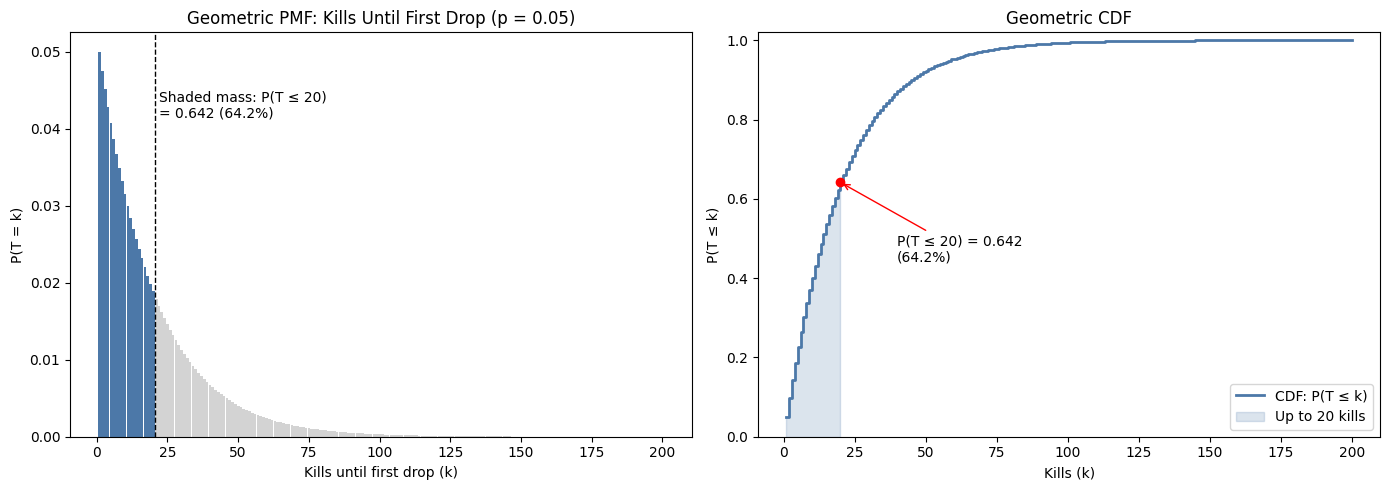

P(at least one drop in 20 kills) = 0.641514 (64.15%)
P(going 20 kills dry) = 0.358486 (35.85%)


In [2]:
import numpy as np
from scipy.stats import geom

import matplotlib.pyplot as plt

# Geometric distribution setup:
# T = number of kills until first drop, with drop chance p each kill
p = 0.05
max_kills = 200
k = np.arange(1, max_kills + 1)

pmf = geom.pmf(k, p)   # P(T = k)
cdf = geom.cdf(k, p)   # P(T <= k)

target_kills = 20
area_upto_target = cdf[target_kills - 1]  # P(T <= 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: PMF with shaded "area" (discrete mass) up to 20 kills ---
colors = np.where(k <= target_kills, "#4C78A8", "#D3D3D3")
axes[0].bar(k, pmf, color=colors, width=0.95, edgecolor="none")
axes[0].set_title("Geometric PMF: Kills Until First Drop (p = 0.05)")
axes[0].set_xlabel("Kills until first drop (k)")
axes[0].set_ylabel("P(T = k)")
axes[0].axvline(target_kills + 0.5, color="black", linestyle="--", linewidth=1)
axes[0].text(
    target_kills + 2,
    pmf.max() * 0.9,
    f"Shaded mass: P(T ≤ {target_kills})\n= {area_upto_target:.3f} ({area_upto_target:.1%})",
    fontsize=10,
    va="top"
)

# --- Chart 2: CDF with highlighted area at 20 kills ---
axes[1].step(k, cdf, where="post", color="#4C78A8", linewidth=2, label="CDF: P(T ≤ k)")
axes[1].fill_between(
    k[k <= target_kills],
    0,
    cdf[k <= target_kills],
    step="post",
    alpha=0.2,
    color="#4C78A8",
    label=f"Up to {target_kills} kills"
)
axes[1].scatter([target_kills], [area_upto_target], color="red", zorder=5)
axes[1].annotate(
    f"P(T ≤ {target_kills}) = {area_upto_target:.3f}\n({area_upto_target:.1%})",
    xy=(target_kills, area_upto_target),
    xytext=(target_kills + 20, area_upto_target - 0.2),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10
)

axes[1].set_title("Geometric CDF")
axes[1].set_xlabel("Kills (k)")
axes[1].set_ylabel("P(T ≤ k)")
axes[1].set_ylim(0, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"P(at least one drop in {target_kills} kills) = {area_upto_target:.6f} ({area_upto_target:.2%})")
print(f"P(going {target_kills} kills dry) = {(1 - p) ** target_kills:.6f} ({((1 - p) ** target_kills):.2%})")